In [2]:
import pandas as pd 
data= pd.read_csv(r'online_retail.csv')

In [3]:
#data.info()
data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

In [4]:
data=data.drop_duplicates()


In [5]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


In [6]:
# Remove rows with missing CustomerID
data = data.dropna(subset=['CustomerID'])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [8]:
# Exclude cancelled invoices (InvoiceNo starting with 'C')
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392732 non-null  object 
 1   StockCode    392732 non-null  object 
 2   Description  392732 non-null  object 
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  object 
 5   UnitPrice    392732 non-null  float64
 6   CustomerID   392732 non-null  float64
 7   Country      392732 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [9]:
# Remove negative or zero quantities and prices
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [10]:
# Remove outliers in Quantity and UnitPrice using IQR
Q1 = data[['Quantity', 'UnitPrice']].quantile(0.25)
Q3 = data[['Quantity', 'UnitPrice']].quantile(0.75)
IQR = Q3 - Q1

# Keep only rows within 1.5*IQR of Q1 and Q3
data = data[
    ((data['Quantity'] >= (Q1['Quantity'] - 1.5 * IQR['Quantity'])) & 
     (data['Quantity'] <= (Q3['Quantity'] + 1.5 * IQR['Quantity']))) &
    ((data['UnitPrice'] >= (Q1['UnitPrice'] - 1.5 * IQR['UnitPrice'])) & 
     (data['UnitPrice'] <= (Q3['UnitPrice'] + 1.5 * IQR['UnitPrice'])))
]

<Axes: title={'center': 'Transaction Volume by Country'}, xlabel='Country'>

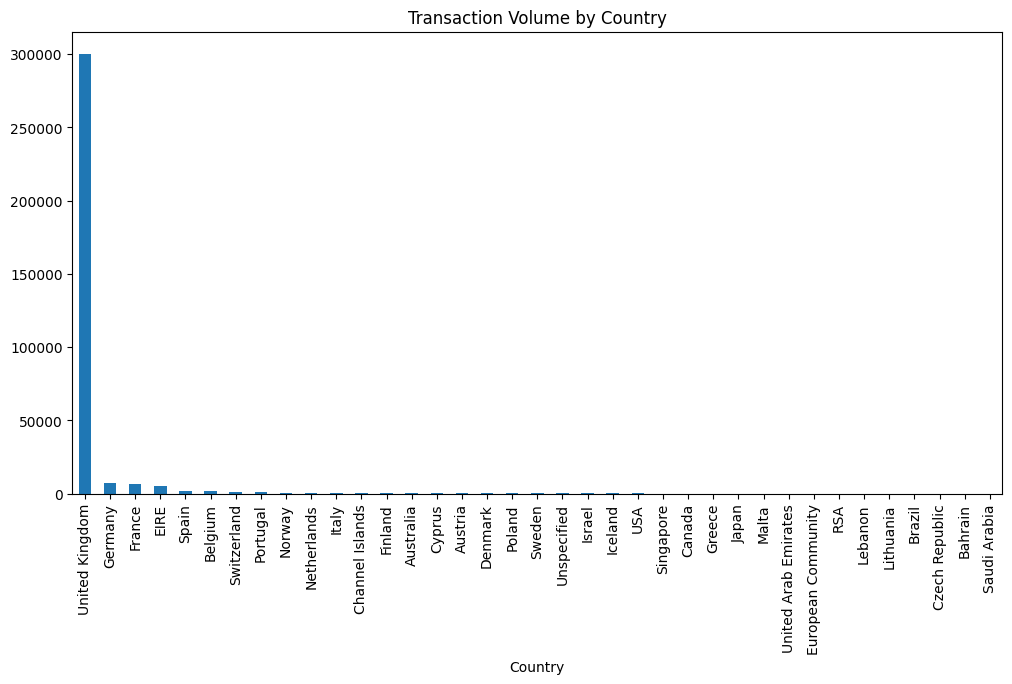

In [11]:
# Transaction volume by country
country_counts = data['Country'].value_counts()
country_counts.plot(kind='bar', figsize=(12,6), title='Transaction Volume by Country')

<Axes: title={'center': 'Top-Selling Products'}, xlabel='Description'>

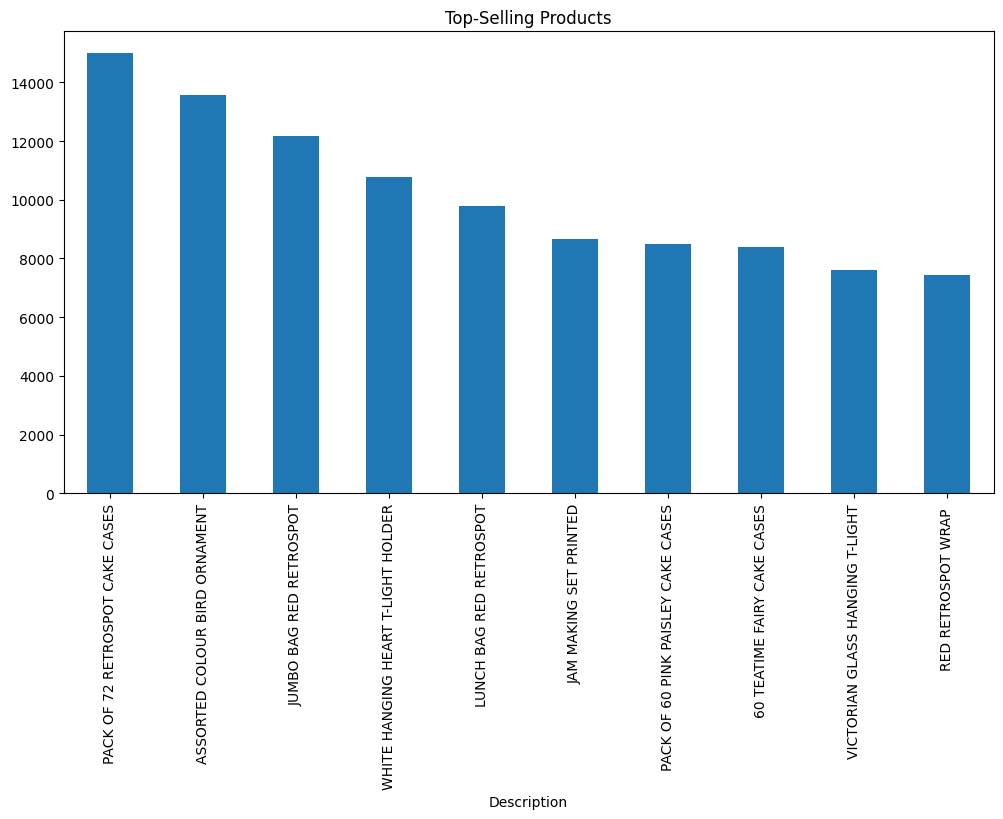

In [12]:
# Top-selling products
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', figsize=(12,6), title='Top-Selling Products')

C:\Users\Admin\AppData\Local\Temp\ipykernel_11032\3017230445.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data.set_index('InvoiceDate').resample('M')['Quantity'].sum()


<Axes: title={'center': 'Monthly Purchase Trends'}, xlabel='InvoiceDate'>

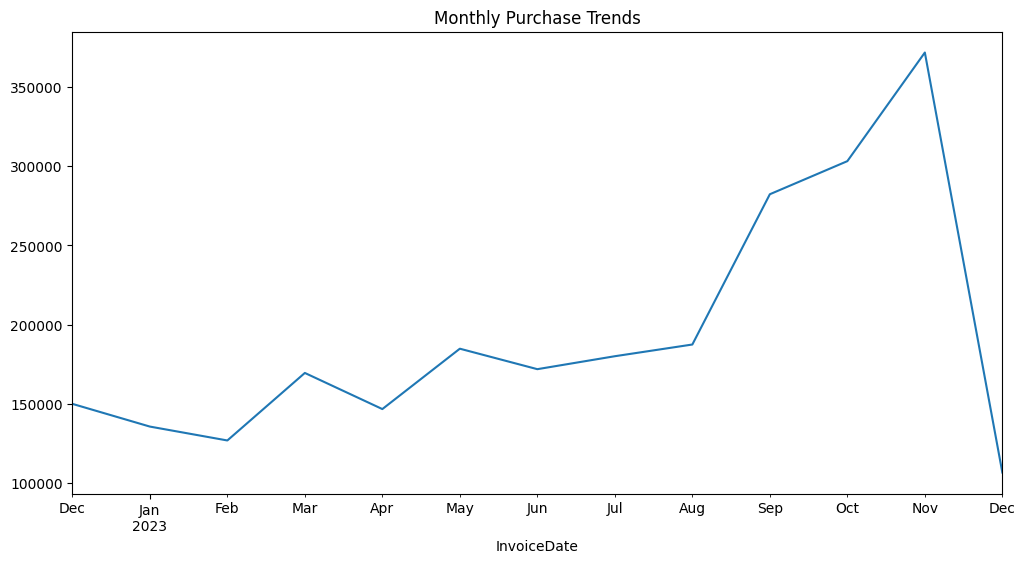

In [13]:
# Purchase trends over time
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
monthly_sales = data.set_index('InvoiceDate').resample('M')['Quantity'].sum()
monthly_sales.plot(figsize=(12,6), title='Monthly Purchase Trends')

<Axes: title={'center': 'Customer Value Distribution'}, ylabel='Frequency'>

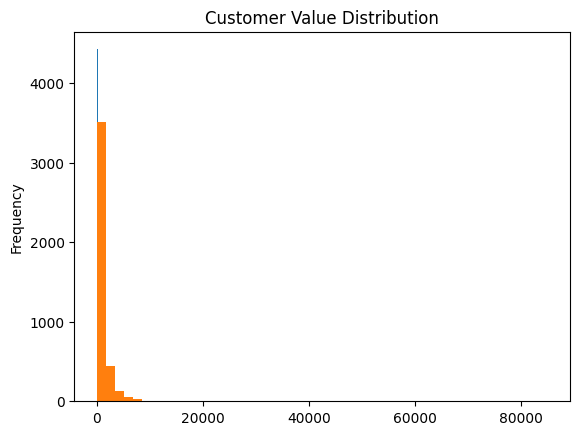

In [14]:
# Monetary value per transaction
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']
transaction_value = data.groupby('InvoiceNo')['TotalPrice'].sum()
transaction_value.plot(kind='hist', bins=50, title='Transaction Value Distribution')

# Monetary value per customer
customer_value = data.groupby('CustomerID')['TotalPrice'].sum()
customer_value.plot(kind='hist', bins=50, title='Customer Value Distribution')

array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

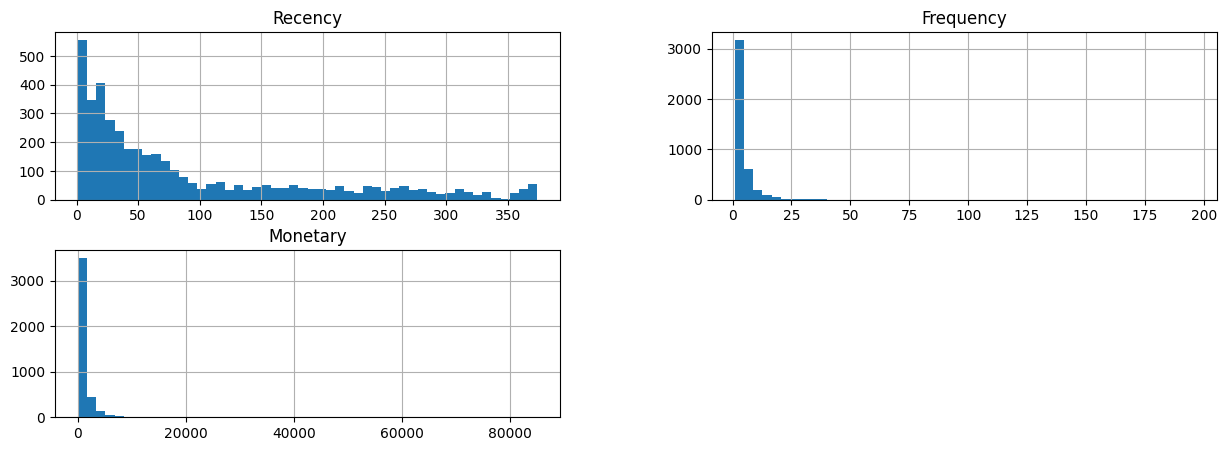

In [15]:
# RFM analysis
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=50, figsize=(15,5))

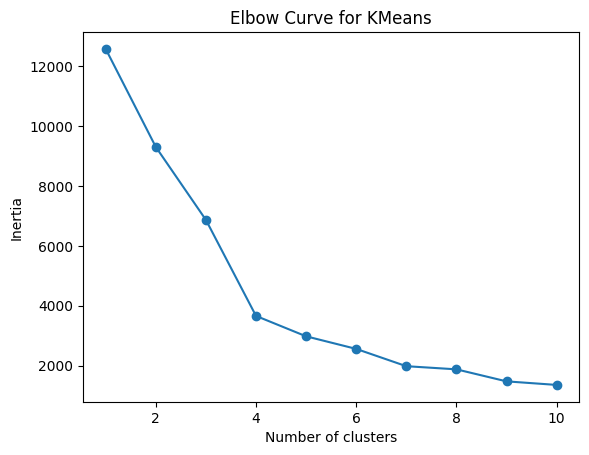

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm_scaled = StandardScaler().fit_transform(rfm)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve for KMeans')
plt.show()

In [17]:
# Assuming optimal k from elbow curve, e.g., k=4
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
cluster_profiles = rfm.groupby('Cluster').mean()
print(cluster_profiles)

            Recency   Frequency      Monetary
Cluster                                      
0         43.755903    3.413542    837.452623
1          2.000000  148.000000  43518.310000
2         13.379310   18.444444   5327.811762
3        246.770554    1.519120    308.776789


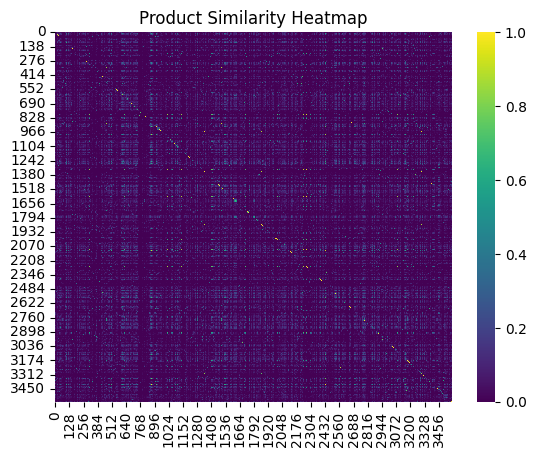

In [18]:
# Product-customer matrix
pivot = data.pivot_table(index='CustomerID', columns='Description', values='Quantity', aggfunc='sum', fill_value=0)

# Cosine similarity between products
from sklearn.metrics.pairwise import cosine_similarity
product_similarity = cosine_similarity(pivot.T)

import seaborn as sns
sns.heatmap(product_similarity, cmap='viridis')
plt.title('Product Similarity Heatmap')
plt.show()

In [19]:
# Calculate Recency for each customer
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = data.groupby('CustomerID')['InvoiceDate'].max().apply(lambda x: (snapshot_date - x).days)
print(recency.head())

CustomerID
12347.0      2
12348.0    249
12349.0     19
12350.0    310
12352.0     36
Name: InvoiceDate, dtype: int64


In [20]:
# Calculate Frequency: Number of transactions per customer
frequency = data.groupby('CustomerID')['InvoiceNo'].nunique()
print(frequency.head())

CustomerID
12347.0    7
12348.0    3
12349.0    1
12350.0    1
12352.0    7
Name: InvoiceNo, dtype: int64


In [21]:
# Calculate Monetary: Total amount spent by customer
monetary = data.groupby('CustomerID')['TotalPrice'].sum()
print(monetary.head())

CustomerID
12347.0    3314.73
12348.0      90.20
12349.0     999.15
12350.0     294.40
12352.0    1130.94
Name: TotalPrice, dtype: float64


In [22]:
from sklearn.preprocessing import StandardScaler

# Standardize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# rfm_scaled is now a numpy array with standardized RFM values
print(rfm_scaled[:5])

[[-0.90586814  0.42552448  1.0404211 ]
 [ 1.56668705 -0.14465315 -0.42532529]
 [-0.73569228 -0.42974197 -0.01215184]
 [ 2.17731809 -0.42974197 -0.33250389]
 [-0.56551641  0.42552448  0.04775478]]


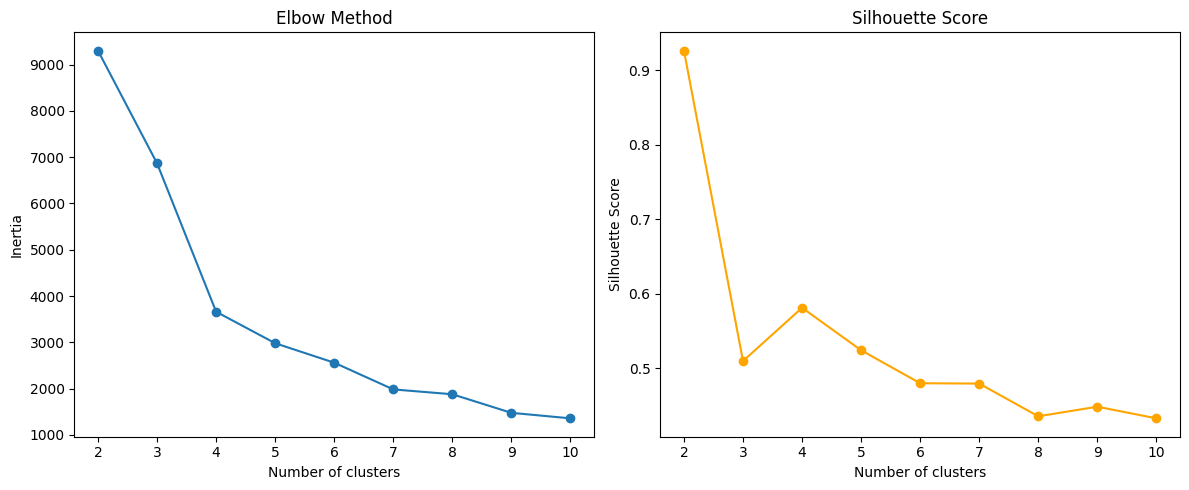

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
K = range(2, 11)  # Start from 2 clusters for silhouette score

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow Curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Plot Silhouette Scores
plt.subplot(1,2,2)
plt.plot(K, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.tight_layout()
plt.show()

In [24]:
# Run KMeans clustering with optimal k (e.g., k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Calculate cluster averages
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_profiles)

# Label clusters based on RFM averages
def label_cluster(row):
    if row['Recency'] < cluster_profiles['Recency'].mean() and \
       row['Frequency'] > cluster_profiles['Frequency'].mean() and \
       row['Monetary'] > cluster_profiles['Monetary'].mean():
        return 'High-Value'
    elif row['Frequency'] > cluster_profiles['Frequency'].median() and \
         row['Monetary'] > cluster_profiles['Monetary'].median():
        return 'Regular'
    elif row['Frequency'] < cluster_profiles['Frequency'].median() and \
         row['Monetary'] < cluster_profiles['Monetary'].median() and \
         row['Recency'] > cluster_profiles['Recency'].median():
        return 'Occasional'
    else:
        return 'At-Risk'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)
print(rfm[['Cluster', 'Segment']].head())

            Recency   Frequency      Monetary
Cluster                                      
0         43.755903    3.413542    837.452623
1          2.000000  148.000000  43518.310000
2         13.379310   18.444444   5327.811762
3        246.770554    1.519120    308.776789
            Cluster     Segment
CustomerID                     
12347.0           0     At-Risk
12348.0           3  Occasional
12349.0           0     At-Risk
12350.0           3  Occasional
12352.0           0  Occasional


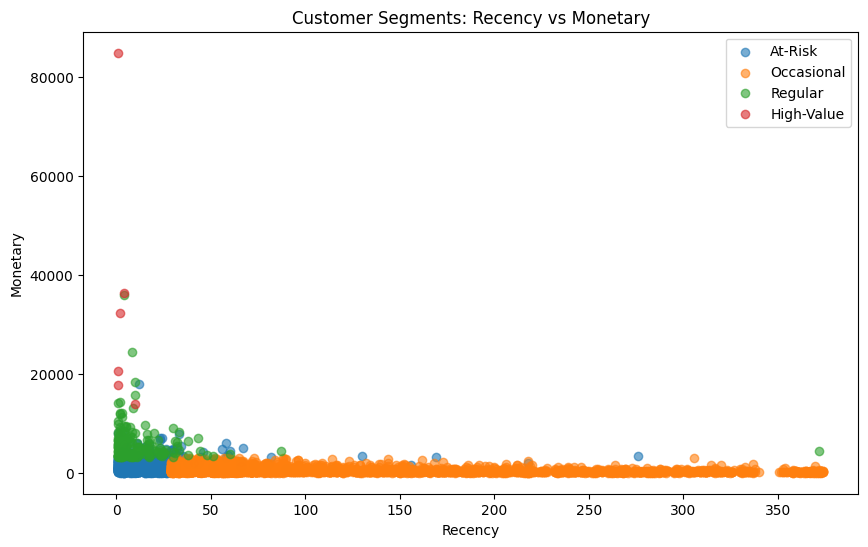

In [25]:
#2D Scatter Plot (Recency vs Monetary):
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for label in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == label]
    plt.scatter(subset['Recency'], subset['Monetary'], label=label, alpha=0.6)
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments: Recency vs Monetary')
plt.legend()
plt.show()

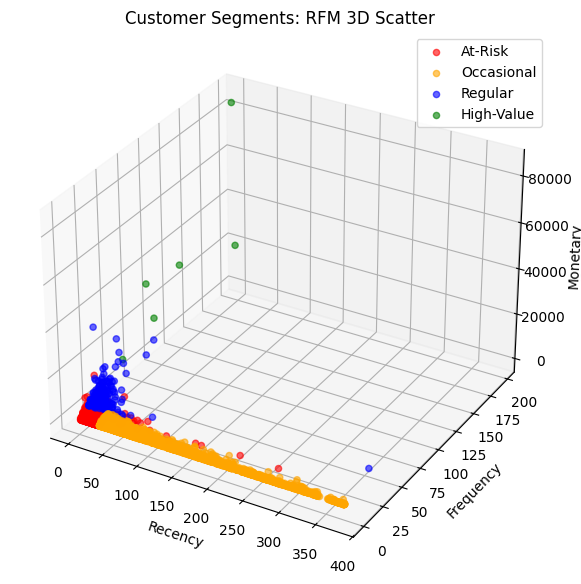

In [26]:
#3D Scatter Plot (Recency, Frequency, Monetary):
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
colors = {'High-Value':'green', 'Regular':'blue', 'Occasional':'orange', 'At-Risk':'red'}
for label in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == label]
    ax.scatter(subset['Recency'], subset['Frequency'], subset['Monetary'],
               c=colors[label], label=label, alpha=0.6)
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.set_title('Customer Segments: RFM 3D Scatter')
ax.legend()
plt.show()

In [ ]:
import joblib

# Save the trained KMeans model
joblib.dump(kmeans, 'kmeans_rfm_model.pkl')

# Optionally, save the scaler if you need to transform new data in Streamlit
joblib.dump(scaler, 'rfm_scaler.pkl')